In [1]:
import pandas as pd
import numpy as np
from pyMyriad import *
from pyMyriad.tabular import flatten

In [2]:
df = pd.DataFrame({
  "id": np.arange(1000),
  "Gender": np.random.choice(["M", "F"], 1000),
  "Age": np.random.randint(18, 70, 1000),
  "Income": np.random.normal(50000, 15000, 1000),
  "Country": np.random.choice(["Benin", "Albania"], 1000),
  "Education": np.random.normal(0, 1, 1000),
  "Employed": np.random.choice([0, 1], 1000)
})

In [3]:
mfun = lambda df: np.mean(df.Income)
nfun = lambda df: np.std(df.Income)
efun = lambda df: np.mean(df.Education)
benin_fun =  lambda df: df.Country == 'Benin'
age_40 = lambda df: df.Age > 40
age_60 = lambda df: df.Age > 60

atree = AnalysisTree()\
  .split_by("df.Gender")\
  .summarize_by(m = mfun, n = nfun)\
  .split_by(label = "Benin Y/N", expr = benin_fun)\
  .split_by(label = "Age Group", age40 = age_40, age60 = age_60)\
  .analyze_by(m = mfun, n = nfun, label = "Income analysis")\
  .analyze_by(m = efun, label = "Education analysis")

res = atree.run(df)


# Forest Plot 
Forest plots are used to represent precomputed statistics from the analysis nodes. Each facet of the plot correspond to the label of the analysis node. This allow the representation of the statistics at different levels. Think of the label as a "scale". You would only represent data from a similar scale in the same diagram even if the statistical function (e.g. the mean) is the same 

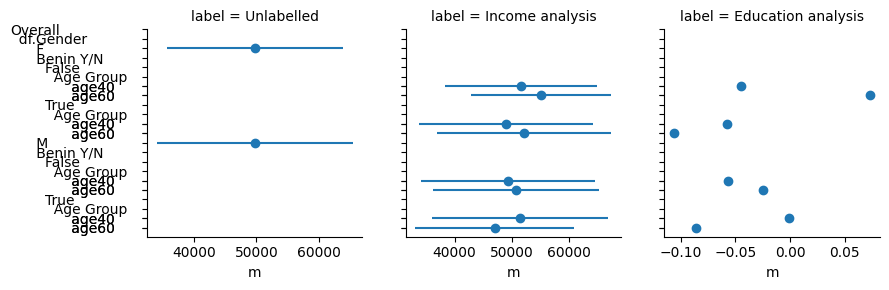

In [4]:
forest_plot(res, x = "m", x_err="n")

for more compact representation, a split can be represented as a color instead of another position on the y axis. Provide the name of the split to the col argument. To avoid overlapping data, one can set the `jitter` argument to `True`.

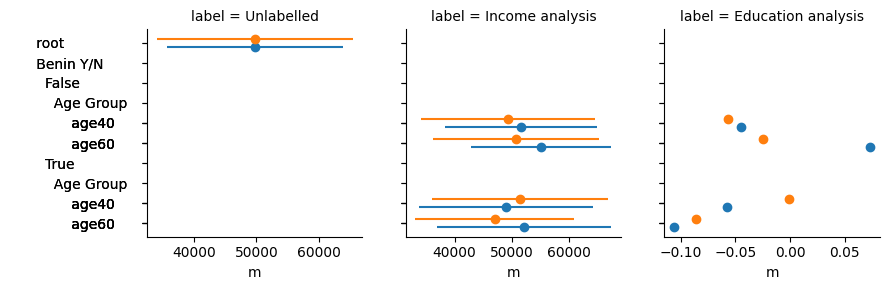

In [5]:
forest_plot(res, x = "m", x_err="n", col = "df.Gender", jitter=True)

Several plot type are supported by `forest_plot`, such as `forest`, `range`, `point` and `bar`.

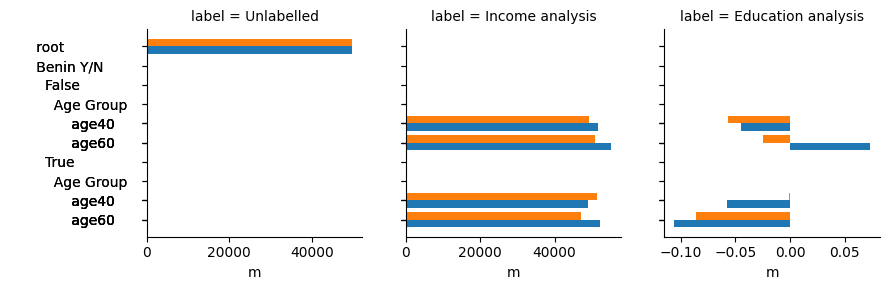

In [6]:
forest_plot(res, x = "m", x_err="n", type="bar", col = "df.Gender", jitter=True)

# Distribution Plot
Use `distribution_plot` to plot the actuall data from a analysis node (not the computed statics). By default the variable represented is the one whose name matches the closest the label of the analysis node, but the user can provide a string matching the name of a column in the original dataframe or a dictionary mapping analysis labels to column name in the original dataframe.

/Users/ben/Projects/pyMyriade/src/pyMyriad/plots.py:282: UserWarning: Warning: x parameter is None. Using column 'Employed' for facet 'Unlabelled'.
  warnings.warn(f"Warning: x parameter is None. Using column '{x_col}' for facet '{current_facet}'.")
/Users/ben/Projects/pyMyriade/src/pyMyriad/plots.py:282: UserWarning: Warning: x parameter is None. Using column 'Income' for facet 'Income analysis'.
  warnings.warn(f"Warning: x parameter is None. Using column '{x_col}' for facet '{current_facet}'.")
/Users/ben/Projects/pyMyriade/src/pyMyriad/plots.py:282: UserWarning: Warning: x parameter is None. Using column 'Income' for facet 'Income analysis'.
  warnings.warn(f"Warning: x parameter is None. Using column '{x_col}' for facet '{current_facet}'.")
/Users/ben/Projects/pyMyriade/src/pyMyriad/plots.py:282: UserWarning: Warning: x parameter is None. Using column 'Education' for facet 'Education analysis'.
  warnings.warn(f"Warning: x parameter is None. Using column '{x_col}' for facet '{curr

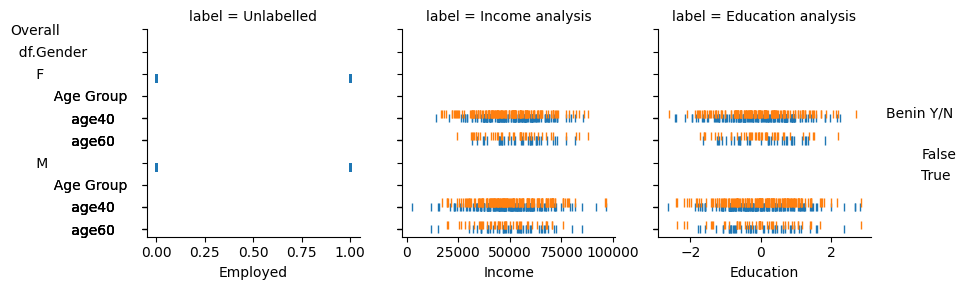

In [13]:
distribution_plot(res, col="Benin Y/N", type="scatter", jitter=True)

The type of available distribution plots are `scatter` `boxplot`, `violin`, 

/Users/ben/Projects/pyMyriade/src/pyMyriad/plots.py:282: UserWarning: Warning: x parameter is None. Using column 'Employed' for facet 'Unlabelled'.
  warnings.warn(f"Warning: x parameter is None. Using column '{x_col}' for facet '{current_facet}'.")
/Users/ben/Projects/pyMyriade/src/pyMyriad/plots.py:282: UserWarning: Warning: x parameter is None. Using column 'Income' for facet 'Income analysis'.
  warnings.warn(f"Warning: x parameter is None. Using column '{x_col}' for facet '{current_facet}'.")
/Users/ben/Projects/pyMyriade/src/pyMyriad/plots.py:282: UserWarning: Warning: x parameter is None. Using column 'Income' for facet 'Income analysis'.
  warnings.warn(f"Warning: x parameter is None. Using column '{x_col}' for facet '{current_facet}'.")
/Users/ben/Projects/pyMyriade/src/pyMyriad/plots.py:282: UserWarning: Warning: x parameter is None. Using column 'Education' for facet 'Education analysis'.
  warnings.warn(f"Warning: x parameter is None. Using column '{x_col}' for facet '{curr

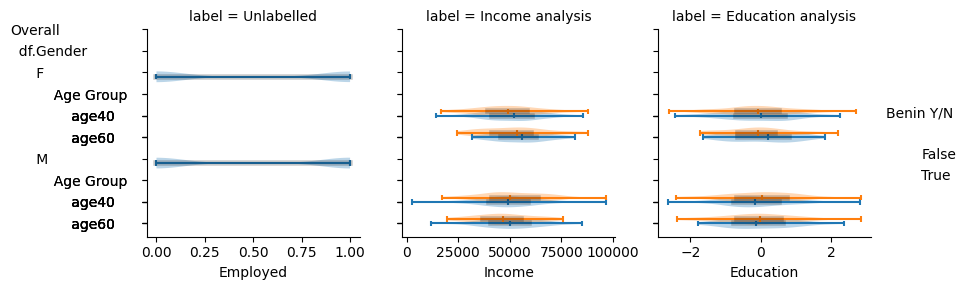

In [12]:
distribution_plot(res, col="Benin Y/N", type="violin", jitter=True)